In [1]:
import pandas as pd

# 1. Veri Setini Yükleme
file_path = "/content/drive/MyDrive/ChatSecOps Test/BenignAndMaliciousDataset.csv"

try:
    # CSV dosyasını pandas DataFrame'e yükle
    df = pd.read_csv(file_path)
    print(f"Veri seti başarıyla yüklendi: {df.shape[0]} satır, {df.shape[1]} sütun.")
    print("--- Verinin ilk 5 satırı (Orijinal) ---")
    print(df.head())
    print("\n" + "="*50 + "\n")

    # 2. Adım: Kayıp Veri Yönetimi (Imputation)
    # Proje dokümanınıza göre 'CountryCode', 'RegisteredOrg' gibi sütunlarda
    # yüksek oranda kayıp veri var[cite: 32].
    # Konuştuğumuz gibi, 'object' (metin) tipindeki tüm sütunlardaki
    # eksik verileri (NaN) "Bilinmiyor" kategorisi ile dolduralım.

    # 'object' tipindeki tüm sütunları seç
    object_columns = df.select_dtypes(include=['object']).columns

    print(f"Kayıp verileri doldurulacak 'object' sütunları: {list(object_columns)}")

    for col in object_columns:
        df[col] = df[col].fillna("Bilinmiyor")

    print("Metin sütunlarındaki kayıp veriler 'Bilinmiyor' ile dolduruldu.")
    print("\n" + "="*50 + "\n")

    # 3. Adım: Kategorik Veri Dönüşümü (One-Hot Encoding)
    # Dokümanınızda belirttiğiniz gibi[cite: 34], 'CountryCode' gibi
    # kategorik özellikleri ML modelinin anlayabilmesi için dönüştürmeliyiz.

    # 'Class' sütunu hedef değişkenimizdir (Y).
    # Bu sütun 'object' tipindeyse (örn: "Zararlı", "Güvenli")
    # OHE listesinden çıkarılmalı ve ayrı olarak 0/1'e çevrilmelidir.
    # Ancak dokümanınızda 'Class' zaten int64 (0/1) görünüyor,
    # bu yüzden onu OHE listesinden (varsa) çıkaralım.

    ohe_columns = list(object_columns)

    if 'Class' in ohe_columns:
        print("Not: 'Class' sütunu hedef değişken (Y) olduğu için OHE dışında tutuluyor.")
        ohe_columns.remove('Class') # Hedef değişkeni özellik yapmayız

    print(f"One-Hot Encoding uygulanacak sütunlar: {ohe_columns}")

    # One-Hot Encoding işlemini uygula
    df_processed = pd.get_dummies(df, columns=ohe_columns, dtype=int)

    print("\n--- İşlenmiş Verinin ilk 5 satırı (OHE sonrası) ---")
    print(df_processed.head())
    print("\n" + "="*50 + "\n")

    print("Veri ön işleme (Imputation ve OHE) başarıyla tamamlandı.")
    print(f"Veri setinin yeni boyutu (OHE sonrası): {df_processed.shape[0]} satır, {df_processed.shape[1]} sütun.")


except FileNotFoundError:
    print(f"HATA: Dosya bulunamadı. '{file_path}' yolunu kontrol edin.")
    print("Eğer Google Colab kullanıyorsanız, Google Drive'ı bağladığınızdan emin olun:")
    print("from google.colab import drive")
    print("drive.mount('/content/drive')")
except Exception as e:
    print(f"Beklenmedik bir hata oluştu: {e}")

Veri seti başarıyla yüklendi: 90000 satır, 34 sütun.
--- Verinin ilk 5 satırı (Orijinal) ---
   Domain DNSRecordType  MXDnsResponse  TXTDnsResponse  HasSPFInfo  \
0    4455             A          False           False       False   
1    4456             A          False           False       False   
2    4457             A          False           False       False   
3    4458             A          False           False       False   
4    4459             A          False           False       False   

   HasDkimInfo  HasDmarcInfo     Ip  DomainInAlexaDB  CommonPorts  ...  \
0        False         False  16984            False        False  ...   
1        False         False  16984            False        False  ...   
2        False         False  16984            False        False  ...   
3        False         False  16984            False        False  ...   
4        False         False  16984            False        False  ...   

  ConsoantRatio NumericRatio  SpecialChar

In [3]:
import pandas as pd

# 1. Veri Setini Yükleme
file_path = "/content/drive/MyDrive/ChatSecOps Test/BenignAndMaliciousDataset.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Orijinal veri seti: {df.shape[0]} satır, {df.shape[1]} sütun.")

    # 2. Adım: Kayıp Veri Yönetimi (Imputation)
    # Önce TÜM object sütunlarındaki kayıp verileri doldur
    object_columns = df.select_dtypes(include=['object']).columns
    for col in object_columns:
        df[col] = df[col].fillna("Bilinmiyor")
    print("Kayıp veriler 'Bilinmiyor' ile dolduruldu.")

    # 3. Adım: Strateji 2.0 - Akıllı Dönüşüm

    # Kural 1: 'RegisteredOrg' sütununu (çok yüksek kardinalite) çıkar
    # 'Domain' sütunu da model için bir özellik değil, bir kimliktir, onu da çıkaralım.
    columns_to_drop = ['RegisteredOrg', 'Domain']
    df_processed = df.drop(columns=columns_to_drop)
    print(f"'RegisteredOrg' ve 'Domain' sütunları çıkarıldı.")

    # Kural 2: 'TLD' sütununu (yüksek kardinalite) grupla
    # En sık kullanılan ilk 30 TLD'yi bul
    top_30_tlds = df_processed['TLD'].value_counts().nlargest(30).index

    # Bu 30 TLD dışındakileri 'TLD_Other' olarak etiketle
    df_processed['TLD_Grouped'] = df_processed['TLD'].apply(
        lambda x: x if x in top_30_tlds else 'TLD_Other'
    )

    # Orijinal 'TLD' sütununa artık ihtiyacımız yok
    df_processed = df_processed.drop(columns=['TLD'])
    print(f"'TLD' sütunu gruplandı ve 'TLD_Grouped' oluşturuldu.")

    # Kural 3: Güvenli sütunlara OHE uygula
    ohe_columns = [
        'DNSRecordType',
        'CountryCode',
        'RegisteredCountry',
        'TLD_Grouped' # Yeni gruplanmış sütunumuz
    ]

    df_processed = pd.get_dummies(df_processed, columns=ohe_columns, dtype=int)
    print(f"Güvenli sütunlara OHE uygulandı: {ohe_columns}")

    # 4. Adım: Sonuç Kontrolü
    print("\n" + "="*50 + "\n")
    print("TÜM ÖN İŞLEME ADIMLARI TAMAMLANDI.")
    print(f"İşlenmiş veri setinin son boyutu: {df_processed.shape[0]} satır, {df_processed.shape[1]} sütun.")
    print("\nİşlenmiş verinin ilk 5 satırı:")
    print(df_processed.head())

    # Yeni sütun sayısını (yaklaşık) hesaplayalım:
    # Orijinal (34) - Düşenler (3) + TLD_Grouped (31) + DNSRecord (3) + CountryCode (109) + RegCountry (114)
    # 31 + 31 + 3 + 109 + 114 = ~288 sütun (tahmini)
    # Bu, 5390'dan çok daha yönetilebilir bir sayıdır.

except Exception as e:
    print(f"Bir hata oluştu: {e}")

Orijinal veri seti: 90000 satır, 34 sütun.
Kayıp veriler 'Bilinmiyor' ile dolduruldu.
'RegisteredOrg' ve 'Domain' sütunları çıkarıldı.
'TLD' sütunu gruplandı ve 'TLD_Grouped' oluşturuldu.
Güvenli sütunlara OHE uygulandı: ['DNSRecordType', 'CountryCode', 'RegisteredCountry', 'TLD_Grouped']


TÜM ÖN İŞLEME ADIMLARI TAMAMLANDI.
İşlenmiş veri setinin son boyutu: 90000 satır, 285 sütun.

İşlenmiş verinin ilk 5 satırı:
   MXDnsResponse  TXTDnsResponse  HasSPFInfo  HasDkimInfo  HasDmarcInfo  \
0          False           False       False        False         False   
1          False           False       False        False         False   
2          False           False       False        False         False   
3          False           False       False        False         False   
4          False           False       False        False         False   

      Ip  DomainInAlexaDB  CommonPorts  CreationDate  LastUpdateDate  ...  \
0  16984            False        False             0   

In [12]:
print(top_30_tlds.to_list())

['com', 'net', 'online', 'com.br', 'org', 'ru', 'sx.cn', 'top', 'blogspot.com', 'info', 'co.uk', 'pl', 'com.au', 'de', 'cn', 'bid', 'it', 'in', 'fr', 'xyz', 'nl', 'es', 'cl', 'ro', 'eu', 'ca', 'us', 'biz', 'cz', 'co.za']


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Bu kodun çalışması için, 'df_processed' DataFrame'inin
# bir önceki adımdaki (285 sütunlu) haliyle hafızada olması gerekir.

try:
    print(f"'df_processed' DataFrame'i ölçeklendirme için hazır. Boyut: {df_processed.shape}")

    # 1. Hedef Değişkeni (Y) ayır
    # 'Class' bizim hedefimiz, onu ölçeklendirmeyeceğiz.
    if 'Class' not in df_processed.columns:
        print("HATA: Hedef değişken 'Class' DataFrame'de bulunamadı.")

    X = df_processed.drop(columns=['Class']) # Özellikler (Features)
    y = df_processed['Class']                 # Hedef (Target)

    print("Hedef değişken 'Class' (y) ve Özellikler (X) ayrıldı.")

    # 2. Ölçeklendirilecek sayısal sütunları bul
    # Orijinal veri setindeki 'object' olmayan sütunları bulmalıyız.
    # OHE sütunları (dtype=int, değerleri 0/1) ve
    # Boolean (True/False) sütunlar ölçeklendirilmemeli.

    # 'float64' tipindeki tüm sütunlar (örn: Entropy)
    float_columns = X.select_dtypes(include=['float64']).columns

    # Değerleri 0 ve 1'den BÜYÜK olan 'int64' sütunları
    # (OHE sütunlarını dışarıda bırakmak için)
    int_columns = []
    for col in X.select_dtypes(include=['int64']).columns:
        # Eğer sütundaki maksimum değer 1'den büyükse, bu bir OHE sütunu değildir.
        if X[col].max() > 1:
            int_columns.append(col)

    # 'bool' (True/False) sütunları 0/1'e çevirelim
    bool_columns = X.select_dtypes(include=['bool']).columns
    for col in bool_columns:
        X[col] = X[col].astype(int)

    # Ölçeklendirilecek nihai sütun listesi
    columns_to_scale = list(float_columns) + list(int_columns)

    print(f"\nÖlçeklendirilecek {len(columns_to_scale)} adet sayısal sütun bulundu:")
    print(columns_to_scale)

    # 3. Ölçeklendirmeyi Uygula
    scaler = StandardScaler()

    # 'fit_transform'U SADECE bu sütunlara uygula
    X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])

    print("\nSayısal özellikler başarıyla ölçeklendirildi (StandardScaler).")

    # 4. Sonuç
    print("\n" + "="*50 + "\n")
    print("VERİ SETİ MODEL EĞİTİMİNE HAZIR.")
    print("\nÖlçeklendirilmiş Özellikler (X) ilk 5 satır:")
    print(X.head())
    print(f"\nÖzellikler (X) son boyut: {X.shape}")
    print(f"Hedef (y) son boyut: {y.shape}")

except NameError:
    print("HATA: 'df_processed' DataFrame'i bulunamadı.")
    print("Lütfen önce 'Strateji 2.0' kodunu çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"Beklenmedik bir hata oluştu: {e}")

'df_processed' DataFrame'i ölçeklendirme için hazır. Boyut: (90000, 285)
Hedef değişken 'Class' (y) ve Özellikler (X) ayrıldı.

Ölçeklendirilecek 18 adet sayısal sütun bulundu:
['ConsoantRatio', 'NumericRatio', 'SpecialCharRatio', 'VowelRatio', 'Ip', 'CreationDate', 'LastUpdateDate', 'ASN', 'HttpResponseCode', 'SubdomainNumber', 'Entropy', 'EntropyOfSubDomains', 'StrangeCharacters', 'ConsoantSequence', 'VowelSequence', 'NumericSequence', 'SpecialCharSequence', 'DomainLength']

Sayısal özellikler başarıyla ölçeklendirildi (StandardScaler).


VERİ SETİ MODEL EĞİTİMİNE HAZIR.

Ölçeklendirilmiş Özellikler (X) ilk 5 satır:
   MXDnsResponse  TXTDnsResponse  HasSPFInfo  HasDkimInfo  HasDmarcInfo  \
0              0               0           0            0             0   
1              0               0           0            0             0   
2              0               0           0            0             0   
3              0               0           0            0             0   

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Bu kodun çalışması için, 'X' (DataFrame) ve 'y' (Series) değişkenlerinin
# bir önceki adımdaki (ölçeklendirilmiş) haliyle hafızada olması gerekir.

try:
    print("Veri seti, model eğitimi için 'X' ve 'y' olarak hazır.")
    print(f"X boyutu: {X.shape}, y boyutu: {y.shape}\n")

    # 1. Adım: Veri Setini Eğitim ve Test Olarak Ayırma
    # Verinin %80'i eğitim, %20'si test için ayrılacak.
    # 'stratify=y' parametresi, 'Class' (0 ve 1) dağılımının
    # hem eğitim hem de test setinde korunmasını sağlar. Bu çok önemlidir.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,    # Verinin %20'sini test için ayır
        random_state=42,  # Tekrarlanabilir sonuçlar için
        stratify=y        # Sınıf dağılımını koru
    )

    print("Veri seti %80 eğitim, %20 test olarak ayrıldı:")
    print(f"X_train boyutu: {X_train.shape}")
    print(f"X_test boyutu: {X_test.shape}\n")

    # 2. Adım: Modeli Oluşturma ve Eğitme
    # Proje dokümanınızda  belirtildiği gibi Lojistik Regresyon ile başlıyoruz.
    print("Lojistik Regresyon modeli oluşturuluyor...")

    # 'max_iter' (maksimum iterasyon) sayısını yüksek tutmak,
    # 284 sütunla modelin yakınsamasına (çözüme ulaşmasına) yardımcı olur.
    model_lr = LogisticRegression(max_iter=1000)

    print("Model, eğitim verisi (X_train, y_train) ile eğitiliyor...")
    # .fit() komutu ile model öğrenmeye başlar
    model_lr.fit(X_train, y_train)

    print("Model başarıyla eğitildi.\n")

    # 3. Adım: Modeli Değerlendirme (Test Verisi ile)
    print("Model, daha önce görmediği test verisi (X_test) ile değerlendiriliyor...")

    # .predict() ile modelin test verisi için tahminlerini al
    y_pred = model_lr.predict(X_test)

    # Modelin genel doğruluk (accuracy) skorunu yazdır
    accuracy = accuracy_score(y_test, y_pred)
    print("\n" + "="*50)
    print(f"Lojistik Regresyon Modeli - Test Doğruluğu: {accuracy * 100:.2f}%")
    print("="*50 + "\n")

    # Daha detaylı metrikler için (Precision, Recall, F1-Score)
    # Bu metrikler, modelin Zararlı (Class 1) ve Güvenli (Class 0)
    # sınıflarını ne kadar iyi ayırdığını gösterir.
    print("Detaylı Sınıflandırma Raporu (Classification Report):")
    print(classification_report(y_test, y_pred))

except NameError:
    print("HATA: 'X' veya 'y' değişkenleri bulunamadı.")
    print("Lütfen önce veri ön işleme adımlarını (scaling) tamamladığınızdan emin olun.")
except Exception as e:
    print(f"Beklenmedik bir hata oluştu: {e}")

Veri seti, model eğitimi için 'X' ve 'y' olarak hazır.
X boyutu: (90000, 284), y boyutu: (90000,)

Veri seti %80 eğitim, %20 test olarak ayrıldı:
X_train boyutu: (72000, 284)
X_test boyutu: (18000, 284)

Lojistik Regresyon modeli oluşturuluyor...
Model, eğitim verisi (X_train, y_train) ile eğitiliyor...
Model başarıyla eğitildi.

Model, daha önce görmediği test verisi (X_test) ile değerlendiriliyor...

Lojistik Regresyon Modeli - Test Doğruluğu: 99.38%

Detaylı Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9000
           1       1.00      0.99      0.99      9000

    accuracy                           0.99     18000
   macro avg       0.99      0.99      0.99     18000
weighted avg       0.99      0.99      0.99     18000



In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 'X_train', 'X_test', 'y_train', 'y_test' değişkenlerinin
# bir önceki adımdan (train_test_split) hafızada olması gerekir.

try:
    print("\n" + "="*50)
    print("Model Eğitimi 2. Adım: Random Forest")
    print("="*50 + "\n")

    print("Random Forest modeli oluşturuluyor...")
    # n_estimators = 100 -> Model 100 adet karar ağacı kullanacak.
    # random_state=42 -> Sonuçların tekrarlanabilir olması için.
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    print("Model, eğitim verisi (X_train, y_train) ile eğitiliyor...")
    # .fit() komutu ile model öğrenmeye başlar
    model_rf.fit(X_train, y_train)

    print("Model başarıyla eğitildi.\n")

    # 3. Adım: Modeli Değerlendirme (Test Verisi ile)
    print("Model, daha önce görmediği test verisi (X_test) ile değerlendiriliyor...")

    # .predict() ile modelin test verisi için tahminlerini al
    y_pred_rf = model_rf.predict(X_test)

    # Modelin genel doğruluk (accuracy) skorunu yazdır
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    print("\n" + "="*50)
    print(f"Random Forest Modeli - Test Doğruluğu: {accuracy_rf * 100:.2f}%")
    print("="*50 + "\n")

    # Detaylı Sınıflandırma Raporu (Lojistik Regresyon ile karşılaştırmak için)
    print("Detaylı Sınıflandırma Raporu (Random Forest):")
    print(classification_report(y_test, y_pred_rf))

except NameError:
    print("HATA: 'X_train' veya 'y_train' değişkenleri bulunamadı.")
    print("Lütfen önce veri ön işleme ve train_test_split adımlarını çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"Beklenmedik bir hata oluştu: {e}")


Model Eğitimi 2. Adım: Random Forest

Random Forest modeli oluşturuluyor...
Model, eğitim verisi (X_train, y_train) ile eğitiliyor...
Model başarıyla eğitildi.

Model, daha önce görmediği test verisi (X_test) ile değerlendiriliyor...

Random Forest Modeli - Test Doğruluğu: 99.69%

Detaylı Sınıflandırma Raporu (Random Forest):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9000
           1       1.00      0.99      1.00      9000

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000




Analiz Adımı: Özellik Önem Düzeyleri (Feature Importance)

Modelin Kararını Etkileyen En Önemli 15 Özellik:
                 Feature  Importance
19          NumericRatio    0.168128
27       DNSRecordType_A    0.119377
24       NumericSequence    0.104306
28   DNSRecordType_CNAME    0.069527
15     StrangeCharacters    0.065566
26          DomainLength    0.064635
18         ConsoantRatio    0.058317
12       SubdomainNumber    0.045459
21            VowelRatio    0.042895
2             HasSPFInfo    0.032178
29      DNSRecordType_MX    0.030454
10                   ASN    0.025984
22      ConsoantSequence    0.019009
5                     Ip    0.018476
275   TLD_Grouped_online    0.014694




/tmp/ipython-input-1821817531.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


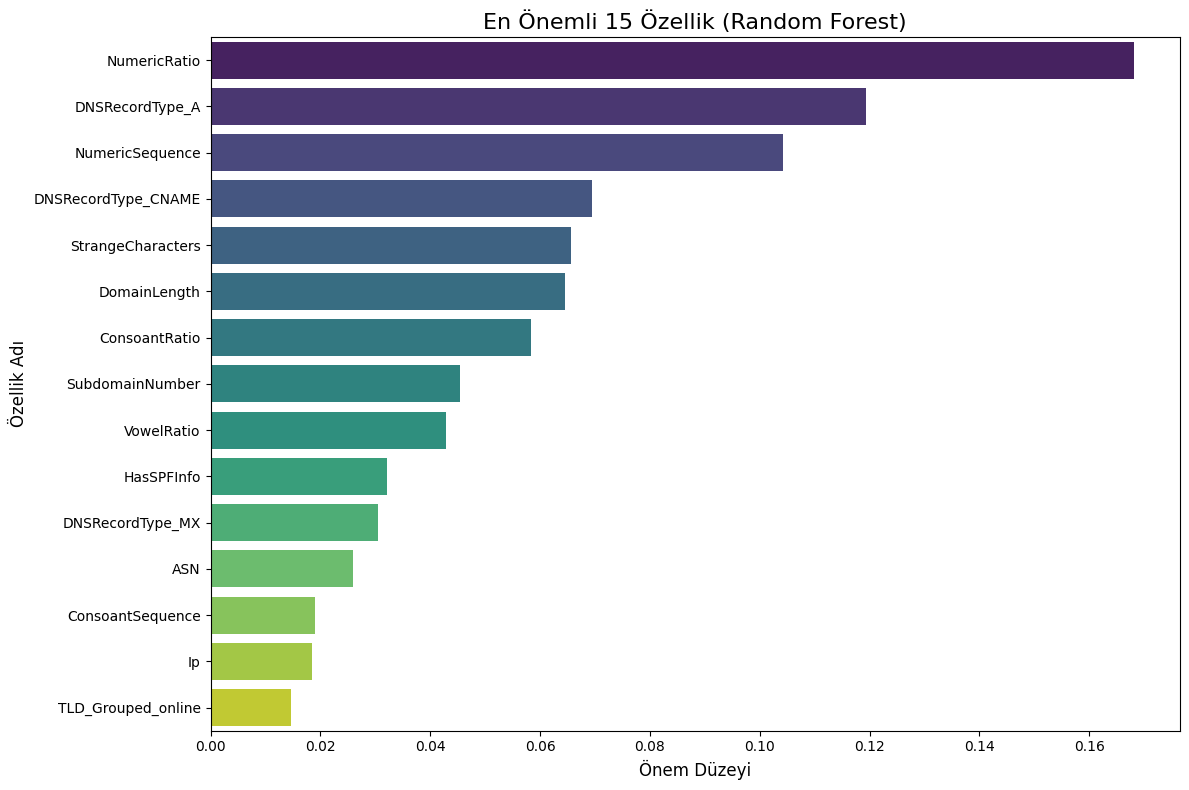

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 'model_rf' (eğitilmiş Random Forest modeli) ve
# 'X' (284 sütunlu özellik DataFrame'i) hafızada olmalı.

try:
    print("\n" + "="*50)
    print("Analiz Adımı: Özellik Önem Düzeyleri (Feature Importance)")
    print("="*50 + "\n")

    # 1. Modelden özellik önem düzeylerini al
    importances = model_rf.feature_importances_

    # 2. Bunları bir DataFrame'e dönüştür
    # Sütun adları (X.columns) ile önem düzeylerini (importances) eşleştir
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })

    # 3. En önemli özellikleri bulmak için sırala
    feature_importance_df = feature_importance_df.sort_values(
        by='Importance',
        ascending=False
    )

    # En önemli 15 özelliği al
    top_15_features = feature_importance_df.head(15)

    print("Modelin Kararını Etkileyen En Önemli 15 Özellik:")
    print(top_15_features)
    print("\n")

    # 4. Görselleştirme (Grafik)
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x='Importance',
        y='Feature',
        data=top_15_features,
        palette='viridis' # Renk paleti
    )
    plt.title('En Önemli 15 Özellik (Random Forest)', fontsize=16)
    plt.xlabel('Önem Düzeyi', fontsize=12)
    plt.ylabel('Özellik Adı', fontsize=12)
    plt.tight_layout() # Grafiğin düzgün sığması için

    # Grafiği göster
    plt.show()

except NameError:
    print("HATA: 'model_rf' veya 'X' değişkenleri bulunamadı.")
    print("Lütfen önce Random Forest modelini eğittiğinizden emin olun.")
except Exception as e:
    print(f"Beklenmedik bir hata oluştu: {e}")

In [8]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

# 'X_train', 'X_test', 'y_train', 'y_test' değişkenlerinin
# hafızada olması gerekir.

try:
    print("\n" + "="*50)
    print("Model Eğitimi 3. Adım: LightGBM (Boosting Modeli)")
    print("="*50 + "\n")

    print("LightGBM modeli oluşturuluyor...")
    # 'boosting_type='gbdt' (Gradient Boosted Decision Tree) standarttır.
    model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

    print("Model, eğitim verisi (X_train, y_train) ile eğitiliyor...")
    model_lgbm.fit(X_train, y_train)

    print("Model başarıyla eğitildi.\n")

    # Modeli Değerlendirme (Test Verisi ile)
    print("Model, daha önce görmediği test verisi (X_test) ile değerlendiriliyor...")
    y_pred_lgbm = model_lgbm.predict(X_test)

    # Modelin genel doğruluk (accuracy) skorunu yazdır
    accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
    print("\n" + "="*50)
    print(f"LightGBM Modeli - Test Doğruluğu: {accuracy_lgbm * 100:.2f}%")
    print("="*50 + "\n")

    print("Detaylı Sınıflandırma Raporu (LightGBM):")
    print(classification_report(y_test, y_pred_lgbm))

except NameError:
    print("HATA: 'X_train' veya 'y_train' değişkenleri bulunamadı.")
    print("Lütfen önce veri ön işleme ve train_test_split adımlarını çalıştırdığınızdan emin olun.")
except Exception as e:
    print(f"Beklenmedik bir hata oluştu: {e}")


Model Eğitimi 3. Adım: LightGBM (Boosting Modeli)

LightGBM modeli oluşturuluyor...
Model, eğitim verisi (X_train, y_train) ile eğitiliyor...
[LightGBM] [Info] Number of positive: 36000, number of negative: 36000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1190
[LightGBM] [Info] Number of data points in the train set: 72000, number of used features: 155
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Model başarıyla eğitildi.

Model, daha önce görmediği test verisi (X_test) ile değerlendiriliyor...

LightGBM Modeli - Test Doğruluğu: 99.75%

Detaylı Sınıflandırma Raporu (LightGBM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9000
           1       1.00      1.00      1.00      9000

    a

In [9]:
import joblib

# 'model_lgbm' ve 'scaler' değişkenlerinin
# önceki adımlardan hafızada olması gerekir.

try:
    # 1. En iyi modeli (LightGBM) kaydet
    model_filename = 'lgbm_domain_classifier.joblib'
    joblib.dump(model_lgbm, model_filename)
    print(f"En iyi model (LightGBM) başarıyla '{model_filename}' dosyasına kaydedildi.")

    # 2. Ölçeklendiriciyi (StandardScaler) kaydet
    # Canlı veriyi dönüştürmek için bu dosyaya da ihtiyacımız var.
    scaler_filename = 'data_scaler.joblib'
    joblib.dump(scaler, scaler_filename)
    print(f"Veri ölçeklendirici (Scaler) başarıyla '{scaler_filename}' dosyasına kaydedildi.")

    print("\nArtık bu iki dosyayı projenizin backend uygulamasında (Flask/FastAPI) kullanabilirsiniz.")

except NameError:
    print("HATA: 'model_lgbm' veya 'scaler' değişkenleri bulunamadı.")
    print("Lütfen önce LightGBM modelini eğittiğinizden ve 'scaler' değişkeninin")
    print("veri ölçeklendirme adımından yüklü olduğundan emin olun.")
except Exception as e:
    print(f"Beklenmedik bir hata oluştu: {e}")

En iyi model (LightGBM) başarıyla 'lgbm_domain_classifier.joblib' dosyasına kaydedildi.
Veri ölçeklendirici (Scaler) başarıyla 'data_scaler.joblib' dosyasına kaydedildi.

Artık bu iki dosyayı projenizin backend uygulamasında (Flask/FastAPI) kullanabilirsiniz.


In [10]:
print(X.columns.to_list())

['MXDnsResponse', 'TXTDnsResponse', 'HasSPFInfo', 'HasDkimInfo', 'HasDmarcInfo', 'Ip', 'DomainInAlexaDB', 'CommonPorts', 'CreationDate', 'LastUpdateDate', 'ASN', 'HttpResponseCode', 'SubdomainNumber', 'Entropy', 'EntropyOfSubDomains', 'StrangeCharacters', 'IpReputation', 'DomainReputation', 'ConsoantRatio', 'NumericRatio', 'SpecialCharRatio', 'VowelRatio', 'ConsoantSequence', 'VowelSequence', 'NumericSequence', 'SpecialCharSequence', 'DomainLength', 'DNSRecordType_A', 'DNSRecordType_CNAME', 'DNSRecordType_MX', 'CountryCode_AD', 'CountryCode_AE', 'CountryCode_AL', 'CountryCode_AR', 'CountryCode_AT', 'CountryCode_AU', 'CountryCode_BA', 'CountryCode_BD', 'CountryCode_BE', 'CountryCode_BG', 'CountryCode_BO', 'CountryCode_BR', 'CountryCode_BS', 'CountryCode_BY', 'CountryCode_Bilinmiyor', 'CountryCode_CA', 'CountryCode_CH', 'CountryCode_CI', 'CountryCode_CL', 'CountryCode_CM', 'CountryCode_CN', 'CountryCode_CO', 'CountryCode_CR', 'CountryCode_CU', 'CountryCode_CW', 'CountryCode_CY', 'Country